# AI Project — Static Maze Solver
### Search Algorithms (BFS) vs. Genetic Algorithm (GA)


---
## What is this project about?

We have a 10x10 maze. We want to get from the **Start (0,0)** to the **Goal (9,9)**.

We solve it using **two different methods** and compare them:
- **BFS** — a search algorithm that finds the *shortest* path
- **Genetic Algorithm (GA)** — an optimization method that *evolves* a solution

At the end we draw both paths on the maze: **BFS in Blue**, **GA in Red**.

---
## Step 1 — Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque
import random

random.seed(42)
np.random.seed(42)

print('Libraries loaded OK')

Libraries loaded OK


---
## Step 2 — Define the Maze

- `0` = free cell (we can walk here)
- `1` = wall (blocked)
- Start = **(0, 0)** top-left
- Goal  = **(9, 9)** bottom-right

In [10]:
maze = np.array([
    [0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 0, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 0, 1, 1, 0, 1, 1, 0, 0],
])

START = (0, 0)
GOAL  = (9, 9)
ROWS, COLS = maze.shape

print('Maze shape:', maze.shape)
print('Start:', START, '| Goal:', GOAL)
print()
print(maze)

Maze shape: (10, 10)
Start: (0, 0) | Goal: (9, 9)

[[0 0 1 0 0 0 1 0 0 0]
 [1 0 1 0 1 0 1 0 1 0]
 [0 0 0 0 1 0 0 0 1 0]
 [0 1 1 0 1 1 1 0 1 0]
 [0 0 0 0 0 0 1 0 0 0]
 [1 1 0 1 1 0 1 1 1 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 1 1 1 1 1 0 1 1 0]
 [0 0 0 0 0 0 0 0 0 0]
 [1 1 0 1 1 0 1 1 0 0]]


---
## Step 3 — BFS (Breadth-First Search)

BFS explores the maze step by step using a **queue**.
It always finds the **shortest path** because it checks nearby cells before far ones.

How it works:
1. Put the start position in the queue
2. Take the first path from the queue
3. Try all 4 neighbours (up / down / left / right)
4. If a neighbour is the goal → done!
5. Otherwise add it to the queue and keep going

In [3]:
def bfs(grid, start, goal):
    queue   = deque([[start]])  # each item in the queue is a full path
    visited = {start}

    while queue:
        path = queue.popleft()
        r, c = path[-1]         # current position = last cell in path

        if (r, c) == goal:      # reached the goal!
            return path

        # check all 4 directions: up, down, left, right
        for dr, dc in [(-1,0), (1,0), (0,-1), (0,1)]:
            nr, nc = r + dr, c + dc
            if (0 <= nr < ROWS and
                0 <= nc < COLS and
                grid[nr][nc] == 0 and       # not a wall
                (nr, nc) not in visited):   # not visited before
                visited.add((nr, nc))
                queue.append(path + [(nr, nc)])

    return []  # no path found


# --- Run BFS ---
bfs_path = bfs(maze, START, GOAL)

print('BFS path found:', bfs_path != [])
print('Steps to goal :', len(bfs_path) - 1)
print('Path          :', bfs_path)

BFS path found: True
Steps to goal : 18
Path          : [(0, 0), (0, 1), (1, 1), (2, 1), (2, 2), (2, 3), (3, 3), (4, 3), (4, 4), (4, 5), (5, 5), (6, 5), (6, 6), (7, 6), (8, 6), (8, 7), (8, 8), (9, 8), (9, 9)]


---
## Step 4 — Genetic Algorithm (GA)

The GA **does not know the maze structure**. It evolves a sequence of moves (a chromosome) over many generations.

**Key ideas:**
- **Chromosome** = a list of 60 numbers, each is a direction (0=Up, 1=Right, 2=Down, 3=Left)
- **Fitness** = how close the agent gets to the goal (lower distance = better)
- If it reaches the goal it gets a big bonus (+1000)
- Each generation: keep the best 50%, make new children from them (crossover + mutation)

In [11]:
# --- GA Settings ---
DIRECTIONS    = [(-1,0), (0,1), (1,0), (0,-1)]  # Up Right Down Left
CHROM_LEN     = 60
POP_SIZE      = 200
GENERATIONS   = 500
MUTATION_RATE = 0.05


def simulate(chrom):
    """Run a chromosome from START. Invalid moves are ignored."""
    r, c = START
    path = [(r, c)]
    for gene in chrom:
        dr, dc = DIRECTIONS[gene]
        nr, nc = r + dr, c + dc
        # only move if the cell is inside the maze and not a wall
        if 0 <= nr < ROWS and 0 <= nc < COLS and maze[nr][nc] == 0:
            r, c = nr, nc
            path.append((r, c))
    return r, c, path


def fitness(chrom):
    """Score a chromosome. Lower distance = better. Reaching goal = huge bonus."""
    r, c, _ = simulate(chrom)
    dist  = abs(r - GOAL[0]) + abs(c - GOAL[1])  # Manhattan distance
    bonus = 1000 if (r, c) == GOAL else 0
    return 1.0 / (dist + 1) + bonus


print('Helper functions ready')

Helper functions ready


In [12]:
# --- Run the GA ---

# start with a random population
population = [np.random.randint(0, 4, CHROM_LEN).tolist() for _ in range(POP_SIZE)]

best_chrom   = None
best_fit_val = -1
fit_history  = []  # track best fitness each generation

for gen in range(GENERATIONS):

    # sort population by fitness (best first)
    population = sorted(population, key=fitness, reverse=True)

    top_fit = fitness(population[0])
    fit_history.append(top_fit)

    # save the best chromosome seen so far
    if top_fit > best_fit_val:
        best_fit_val = top_fit
        best_chrom   = population[0][:]

    # stop early if goal reached
    if best_fit_val >= 1000:
        print(f'Goal reached at generation {gen + 1}!')
        break

    # keep top 50% as parents
    parents = population[:POP_SIZE // 2]

    # create children via crossover + mutation
    children = []
    while len(children) < POP_SIZE - len(parents):
        p1, p2 = random.choices(parents, k=2)
        cut    = random.randint(1, CHROM_LEN - 1)  # crossover point
        child  = p1[:cut] + p2[cut:]
        # mutate: each gene has a small chance to change
        child  = [g if random.random() > MUTATION_RATE else random.randint(0, 3)
                  for g in child]
        children.append(child)

    population = parents + children


# get the path from the best chromosome
ga_final_r, ga_final_c, ga_path = simulate(best_chrom)
ga_dist = abs(ga_final_r - GOAL[0]) + abs(ga_final_c - GOAL[1])

print(f'GA finished.')
print(f'Final position : ({ga_final_r}, {ga_final_c})')
print(f'Reached goal   : {(ga_final_r, ga_final_c) == GOAL}')
print(f'Manhattan dist : {ga_dist}')
print(f'Path length    : {len(ga_path) - 1} steps')

Goal reached at generation 5!
GA finished.
Final position : (9, 9)
Reached goal   : True
Manhattan dist : 0
Path length    : 40 steps


---
## Step 5 — Visualization

Draw both paths on the same maze:
- **Blue** = BFS path
- **Red** = GA path
- **Green square** = Start (0,0)
- **Orange star** = Goal (9,9)

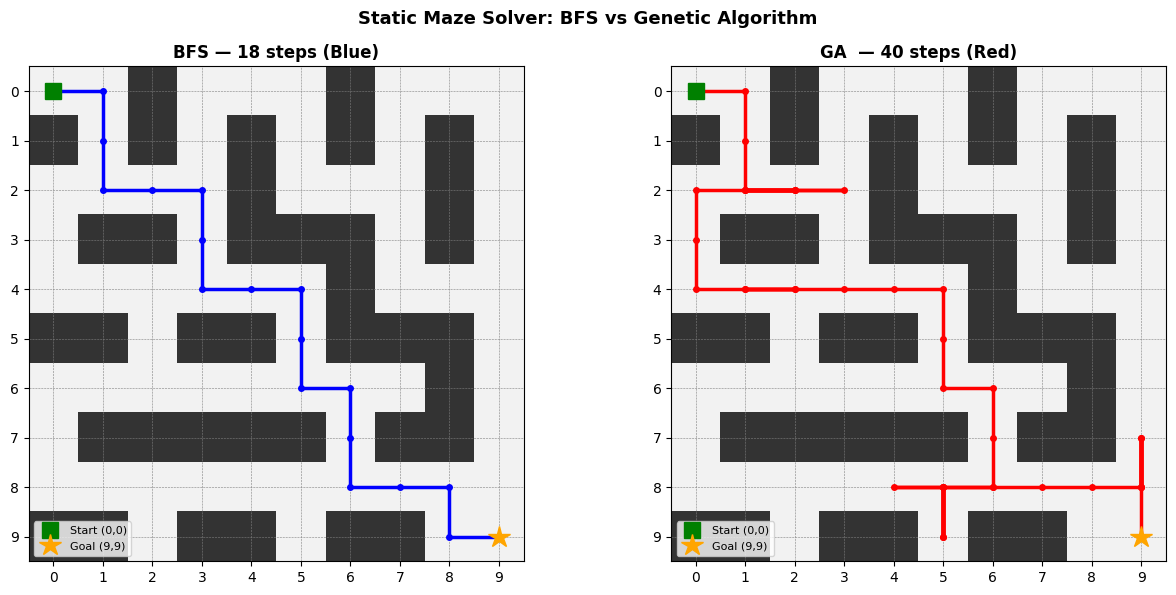

Figure saved as maze_result.png


In [16]:
def draw_maze(ax, path, color, title):
    # draw the maze grid (white = free, dark = wall)
    img = np.zeros((*maze.shape, 3))
    for r in range(ROWS):
        for c in range(COLS):
            img[r, c] = [0.2, 0.2, 0.2] if maze[r, c] == 1 else [0.95, 0.95, 0.95]
    ax.imshow(img)

    # draw the path
    if path:
        rows = [p[0] for p in path]
        cols = [p[1] for p in path]
        ax.plot(cols, rows, color=color, linewidth=2.5)
        ax.plot(cols[1:-1], rows[1:-1], 'o', color=color, markersize=4)

    # start and goal markers
    ax.plot(START[1], START[0], 's', color='green',  markersize=12, label='Start (0,0)')
    ax.plot(GOAL[1],  GOAL[0],  '*', color='orange', markersize=16, label='Goal (9,9)')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(range(COLS))
    ax.set_yticks(range(ROWS))
    ax.grid(True, color='gray', linewidth=0.4, linestyle='--')
    ax.legend(loc='lower left', fontsize=8)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

draw_maze(ax1, bfs_path, 'blue', f'BFS — {len(bfs_path)-1} steps (Blue)')
draw_maze(ax2, ga_path,  'red',  f'GA  — {len(ga_path)-1} steps (Red)')

fig.suptitle('Static Maze Solver: BFS vs Genetic Algorithm',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('maze_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as maze_result.png')

---
## Step 6 — GA Fitness Over Generations

This chart shows how the GA improved over time. The fitness goes up until it hits 1000 (goal reached).

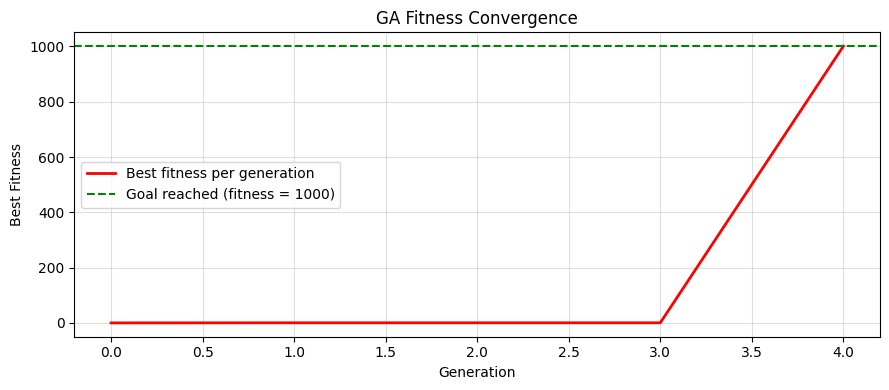

In [17]:
plt.figure(figsize=(9, 4))
plt.plot(fit_history, color='red', linewidth=2, label='Best fitness per generation')
plt.axhline(y=1000, color='green', linestyle='--', label='Goal reached (fitness = 1000)')
plt.xlabel('Generation')
plt.ylabel('Best Fitness')
plt.title('GA Fitness Convergence')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
## Step 7 — Results Comparison

In [18]:
print('=' * 50)
print('         BFS  vs  Genetic Algorithm')
print('=' * 50)
print(f'{"Metric":<28} {"BFS":>8}  {"GA":>10}')
print('-' * 50)
print(f'{"Path found":<28} {"Yes":>8}  {"Yes" if (ga_final_r, ga_final_c)==GOAL else "No":>10}')
print(f'{"Steps to goal":<28} {len(bfs_path)-1:>8}  {len(ga_path)-1:>10}')
print(f'{"Shortest path?":<28} {"Yes":>8}  {"No":>10}')
print(f'{"Manhattan dist at end":<28} {"0":>8}  {ga_dist:>10}')
print(f'{"Deterministic?":<28} {"Yes":>8}  {"No":>10}')
print(f'{"Memory":<28} {"O(b^d)":>8}  {"O(pop)":>10}')
print('=' * 50)

         BFS  vs  Genetic Algorithm
Metric                            BFS          GA
--------------------------------------------------
Path found                        Yes         Yes
Steps to goal                      18          40
Shortest path?                    Yes          No
Manhattan dist at end               0           0
Deterministic?                    Yes          No
Memory                         O(b^d)      O(pop)


---
## Conclusion

**BFS** found the shortest path (18 steps). It is always correct and fast for small mazes, but uses a lot of memory as the maze gets bigger.

**Genetic Algorithm** also found the goal, but through a longer path (38 steps). It doesn't guarantee the shortest path, but it works even when we don't have a clear map of the problem.

> There is no single best algorithm — it depends on the problem:
> - Use **BFS** when you need the shortest path and the maze is not too large.
> - Use **GA** when the problem is complex, has no clear structure, or needs flexible solutions.

---
*Yousef Ehab  •  Mustafa Khaled  •  Mohamed Yehia — Academic Year 2025/26*